# RSM338 Assignment 6 Part B: Regression
## 5. The Black-Scholes Formula
### 5.1 Generating Call Option Data

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch

# Define the Black-Scholes function for Call Options
def black_scholes_call(S, K, T, r, sigma):
    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate call price
    call_price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    return call_price

# Set seed for reproducibility
np.random.seed(23)
n_samples = 100000

# Sample inputs uniformly from the specified ranges
S0 = np.random.uniform(40, 60, n_samples)
# K depends on S0, so we sample it relative to the S0 array
K = np.random.uniform(0.5 * S0, 1.5 * S0, n_samples) 
T = np.random.uniform(0.25, 2.0, n_samples)
r = np.random.uniform(0, 0.05, n_samples)
sigma = np.random.uniform(0.10, 0.40, n_samples)

# Calculate the true Black-Scholes price for all 100,000 contracts simultaneously
C = black_scholes_call(S0, K, T, r, sigma)

# Combine into a DataFrame
df_bs = pd.DataFrame({
    'S0': S0, 'K': K, 'T': T, 'r': r, 'sigma': sigma, 'Call_Price': C
})

df_bs.head()

Generated 100000 Black-Scholes samples.


,S0,K,T,r,sigma,Call_Price
0,50.345958,33.297847,1.671844,0.020493,0.201643,18.352483
1,58.939252,79.685795,0.889926,0.020344,0.130935,0.031118
2,55.309195,37.551077,1.241290,0.008531,0.206519,18.330442
3,45.647917,62.834540,0.796120,0.039218,0.319233,1.214502
4,44.420907,30.589633,1.437705,0.010145,0.381525,16.095141


### 5.2 Fitting Linear Regression

In [2]:
# Separate features (X) and target (y)
X = df_bs[['S0', 'K', 'T', 'r', 'sigma']].values
y = df_bs['Call_Price'].values.reshape(-1, 1) # Reshape for neural network target

# 1. First split: 20% to Test, 80% to Temp
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 2. Second split: 25% of Temp (which is 20% of total) to Val, rest to Train
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

# Standardize the inputs based ONLY on the training set
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Convert all splits to PyTorch FloatTensors
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

print(f"Train shapes: X={X_train_t.shape}, y={y_train_t.shape}")
print(f"Val shapes: X={X_val_t.shape}, y={y_val_t.shape}")
print(f"Test shapes: X={X_test_t.shape}, y={y_test_t.shape}")

Train shapes: X=torch.Size([60000, 5]), y=torch.Size([60000, 1])
Val shapes: X=torch.Size([20000, 5]), y=torch.Size([20000, 1])
Test shapes: X=torch.Size([20000, 5]), y=torch.Size([20000, 1])


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Initialize and fit the Linear Regression model on the training set
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# 2. Generate predictions on the unseen test set
lr_predictions = lr_model.predict(X_test_scaled)

# 3. Calculate Mean Squared Error (MSE) and R-squared (R^2)
lr_mse = mean_squared_error(y_test, lr_predictions)
lr_r2 = r2_score(y_test, lr_predictions)

print(f"Linear Regression Test MSE: {lr_mse:.4f}")
print(f"Linear Regression Test R^2: {lr_r2:.4f}")

Linear Regression Test MSE: 6.0794
Linear Regression Test R^2: 0.8991


The results of the linear regression appear to be promising at first. The R-squared is quite high, at 0.899. However, this is quite misleading, as the mean-squared error (MSE) is quite high at 6.08, which suggests that the regression is unable to fit the true pattern of the data. Essentially, the linear regression is able to capture the general direction of the relationship, as there are strong relationships like stock and call prices, but it does not help predict call option prices because as we know, the Black-Scholes equation is quite non-linear. For example, when options move from in-the-money (ITM) to out-the-money (OTM), we know that the movement in option price is non-linear, and that linear regressions are unable to bend to capture this, leading to that high MSE. For this reason, this non-linear data would be much better captured by a neural network, which is much more flexible and can fit the movement of call prices.

### 5.3 Building and Training a Neural Network

To model the Black-Scholes formula, we constructed a feed-forward neural network with three hidden layers of 64 neurons each. Unlike the classification task in Part A, we replaced the standard ReLU activation functions with Tanh for the hidden layers and Softplus for the output layer. The Tanh function outputs values along a smooth S-shaped curve, and since the true Black-Scholes model shows continuous, non-linear curves, Tanh allows the network to fit these curves more efficiently because it does not need excessive piecewise linear approximations that ReLU does. Furthermore, we applied Softplus to the final output neuron. Softplus is a smooth approximation of ReLU that restricts the output strictly to positive values, as the price of a call option cannot drop below zero.

We decided to use three hidden layers with 64 neurons each. The Black-Scholes formula is highly non-linear and has complex interactions with the inputs (e.g., time affects volatility's impact on price). Three layers should be deep enough to capture these relatively complex interactions, but not to the point that the model is unstable, as there are only five inputs. 64 neurons is quite standard, and we felt that going lower would make our model too stiff, and that additional neurons would add much more training time without much benefit given we only have five inputs. For optimization and learning rate, we went with Adam and 0.001. Adam is quite standard for tabular data, and because it is able to slow down the learning rate, we felt like 0.001 was a safe upper-limit since 0.01 felt too large. We went with 100 epochs and a batch size of 512, as we felt like it would provide ample noise for Adam to build up enough momentum get past saddle points while keep training time reasonable, given that we now have 100,000 observations. Had we used a batch size of 64 and 500 epochs like earlier, the network would take very long to run with no benefit. Since the Black-Scholes formula is deterministic rather than noisy, the model converges rapidly; running 500 epochs would simply result in the optimizer plateauing and wasting resources.

In [8]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import copy
import matplotlib.pyplot as plt
import torch

# Set seed for reproducibility
torch.manual_seed(23)

# 1. Define the Neural Network Architecture
class BlackScholesNet(nn.Module):
    def __init__(self, input_size):
        super(BlackScholesNet, self).__init__()
        # 3 hidden layers with 64 neurons each provides enough flexibility for the curve
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        
        # Activations required by the assignment
        self.tanh = nn.Tanh()
        self.softplus = nn.Softplus()

    def forward(self, x):
        x = self.tanh(self.fc1(x))
        x = self.tanh(self.fc2(x))
        x = self.tanh(self.fc3(x))
        # Softplus applied only to the final output to ensure price > 0
        x = self.softplus(self.output(x))
        return x

# 2. Initialize Model, Loss, and Optimizer
input_dim = X_train_t.shape[1]
bs_model = BlackScholesNet(input_dim)
criterion = nn.MSELoss() # Mean Squared Error for regression
optimizer = optim.Adam(bs_model.parameters(), lr=0.001)

# 3. Create DataLoaders
# Using a larger batch size (512) since we have 100,000 rows
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

epochs = 100
train_losses = []
val_losses = []
best_val_loss = float('inf')
best_bs_weights = None

# 4. Training Loop
for epoch in range(epochs):
    bs_model.train()
    epoch_train_loss = 0.0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = bs_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item() * batch_X.size(0)
        
    avg_train_loss = epoch_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)
    
    # Validation Phase
    bs_model.eval()
    with torch.no_grad():
        val_outputs = bs_model(X_val_t)
        val_loss = criterion(val_outputs, y_val_t).item()
        val_losses.append(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_bs_weights = copy.deepcopy(bs_model.state_dict())
            
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Train MSE: {avg_train_loss:.4f}, Val MSE: {val_loss:.4f}')

Epoch [10/100], Train MSE: 0.1756, Val MSE: 0.1525
Epoch [20/100], Train MSE: 0.0192, Val MSE: 0.0172
Epoch [30/100], Train MSE: 0.0052, Val MSE: 0.0048
Epoch [40/100], Train MSE: 0.0022, Val MSE: 0.0030
Epoch [50/100], Train MSE: 0.0014, Val MSE: 0.0010
Epoch [60/100], Train MSE: 0.0010, Val MSE: 0.0008
Epoch [70/100], Train MSE: 0.0008, Val MSE: 0.0005
Epoch [80/100], Train MSE: 0.0006, Val MSE: 0.0004
Epoch [90/100], Train MSE: 0.0005, Val MSE: 0.0006
Epoch [100/100], Train MSE: 0.0005, Val MSE: 0.0004


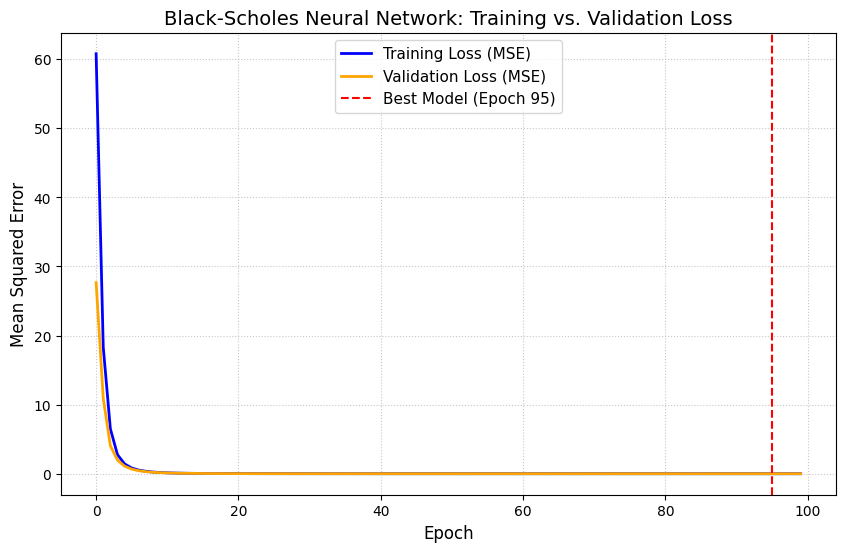

In [9]:
# Plotting the Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(val_losses, label='Validation Loss (MSE)', color='orange', linewidth=2)

# Find and plot the best epoch
best_epoch = val_losses.index(min(val_losses))
plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Model (Epoch {best_epoch})')

plt.title('Black-Scholes Neural Network: Training vs. Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

As seen in the plot, the loss curves demonstrate rapid and stable convergence unlike with the Lending Club data. Because the Black-Scholes dataset is synthetic and deterministic, which means it contains no underlying noise, both the training and validation Mean Squared Error (MSE) drop steeply in the initial epochs and plateau near zero. Unlike the noisy Lending Club classification task, this regression model exhibits no severe overfitting. Furthermore, the fact that the minimum validation loss occurs at Epoch 95 validates our hyperparameter choices. It indicates that 100 epochs was the ideal training duration, since the network could optimize its weights right up to the end without wasting resources.

### 5.4 Neural Network Test Set Comparison with Linear Regression

In [12]:
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the best weights from the training loop
bs_model.load_state_dict(best_bs_weights)
bs_model.eval()

# 2. Generate predictions on the Test Set
with torch.no_grad():
    nn_predictions = bs_model(X_test_t).numpy()

# 3. Calculate metrics for the Neural Network
nn_mse = mean_squared_error(y_test, nn_predictions)
nn_r2 = r2_score(y_test, nn_predictions)

print(f"Neural Network Test MSE: {nn_mse:.4f} (vs LR: {lr_mse:.4f})")
print(f"Neural Network Test R^2: {nn_r2:.4f} (vs LR: {lr_r2:.4f})")

Neural Network Test MSE: 0.0002 (vs LR: 6.0794)
Neural Network Test R^2: 1.0000 (vs LR: 0.8991)


As expected, the neural network significantly outperforms the linear regression on the test set metrics. While the neural network achieves a perfect R-squared of 1.0000 compared to the linear regression's 0.8991, the Mean Squared Error (MSE) illustrates exactly why neural networks are critical for options pricing. The linear regression's MSE of 6.0794 reveals a severe inability to price accurately despite a seemingly acceptable R-squared, whereas the neural network's MSE is a negligible 0.0002. This discrepancy occurs because the neural network possesses the necessary depth and width to flexibly fit the non-linear curvature of the Black-Scholes model.

### 5.5 Scatter Plot -- Predicted vs Actual Black-Scholes Prices

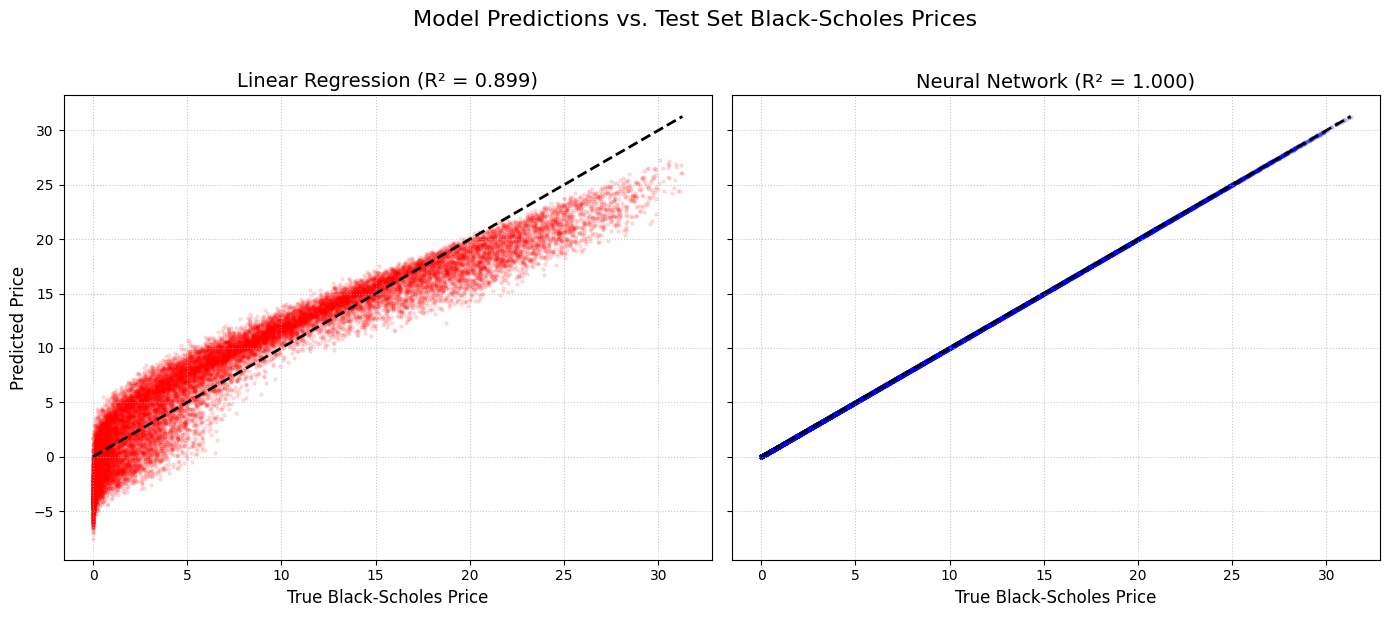

In [13]:
# 4. Generate Scatter Plots for Problem 5(e)
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Scatter plot for Linear Regression
axes[0].scatter(y_test, lr_predictions, alpha=0.1, color='red', s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # 45-degree line
axes[0].set_title(f'Linear Regression (R² = {lr_r2:.3f})', fontsize=14)
axes[0].set_xlabel('True Black-Scholes Price', fontsize=12)
axes[0].set_ylabel('Predicted Price', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.7)

# Scatter plot for Neural Network
axes[1].scatter(y_test, nn_predictions, alpha=0.1, color='blue', s=5)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2) # 45-degree line
axes[1].set_title(f'Neural Network (R² = {nn_r2:.3f})', fontsize=14)
axes[1].set_xlabel('True Black-Scholes Price', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.7)

plt.suptitle('Model Predictions vs. Test Set Black-Scholes Prices', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The rigidity of the linear regression is highly apparent in the scatter plot. It even predicts negative call prices, which we know is impossible. Because the linear model attempts to capture the general trend but cannot bend to match the true function's convexity, it systematically underprices highly valuable options and overprices cheaper ones. Conversely, the neural network utilizes its flexibility optimally, perfectly predicting the call prices for every observation and completely overlapping the 45-degree baseline. Because there is no noise in this synthetic dataset, our neural network has effectively reverse-engineered the formula itself; a feat that highlights its predicting power, though this level of perfection may not be attainable with noisy, real-world financial data.